In [24]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [26]:
#Cargamos el archivo de dataset Kaggle
df = pd.read_csv('TIENDA RETAIL.csv', sep=';')


In [27]:
#Vizualición de las columnas
print(df.columns)

Index(['Fecha', 'Store ID', 'Product ID', 'Categoria', 'Region',
       'Inventory Level', 'Unidad Vendida', 'Unidades Ordenadas', 'Precio',
       'Descuento', 'Condiciones Climaticas', 'Promoción',
       'Precios de la competencia', 'Estacionalidad', 'Epidemic', 'Demanda'],
      dtype='object')


In [28]:
#Visualizamos los primeros 5 datos
df.head(10)

,Fecha,Store ID,Product ID,Categoria,Region,Inventory Level,Unidad Vendida,Unidades Ordenadas,Precio,Descuento,Condiciones Climaticas,Promoción,Precios de la competencia,Estacionalidad,Epidemic,Demanda
0,1/01/2022,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,1/01/2022,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,1/01/2022,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,1/01/2022,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,1/01/2022,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,1/01/2022,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,1/01/2022,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,1/01/2022,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,1/01/2022,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,1/01/2022,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [29]:
print(df.dtypes)

Fecha                         object
Store ID                      object
Product ID                    object
Categoria                     object
Region                        object
Inventory Level                int64
Unidad Vendida                 int64
Unidades Ordenadas             int64
Precio                       float64
Descuento                      int64
Condiciones Climaticas        object
Promoción                      int64
Precios de la competencia    float64
Estacionalidad                object
Epidemic                       int64
Demanda                        int64
dtype: object


Text(0, 0.5, 'Frecuencia')

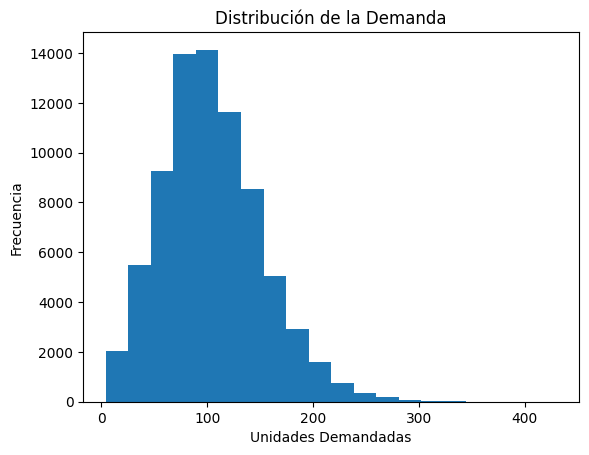

In [30]:
#Histograma de Demanda 
plt.hist(df['Demanda'].dropna(), bins=20)
plt.title('Distribución de la Demanda')
plt.xlabel('Unidades Demandadas')
plt.ylabel('Frecuencia')

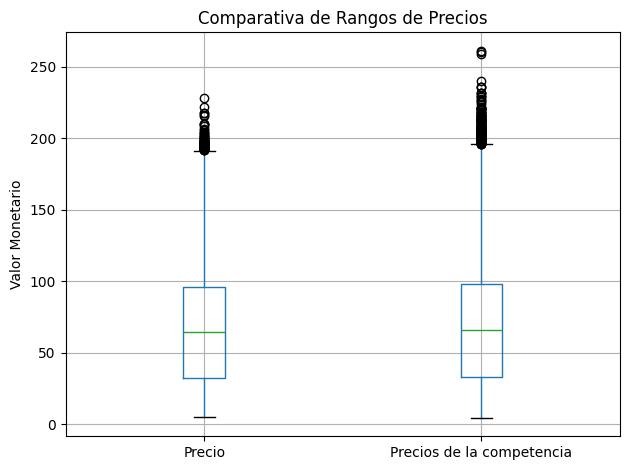

In [31]:
#Boxplot de Precios (Para ver valores atípicos y rangos)
# Creamos un boxplot comparativo
df.boxplot(column=['Precio', 'Precios de la competencia'])
plt.title('Comparativa de Rangos de Precios')
plt.ylabel('Valor Monetario')

plt.tight_layout()
plt.show()

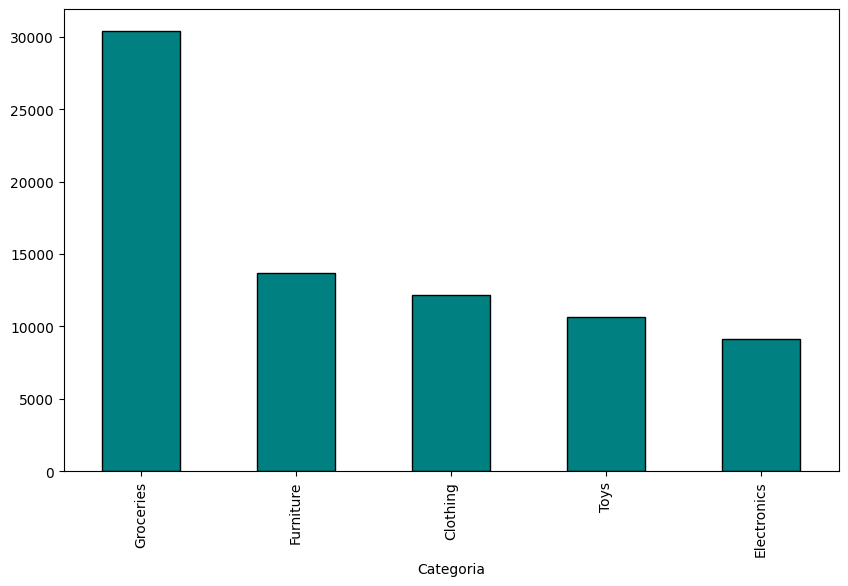

In [32]:
#Configurar el gráfico de barras para 'Categoria'
plt.figure(figsize=(10, 6))
df['Categoria'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.show()

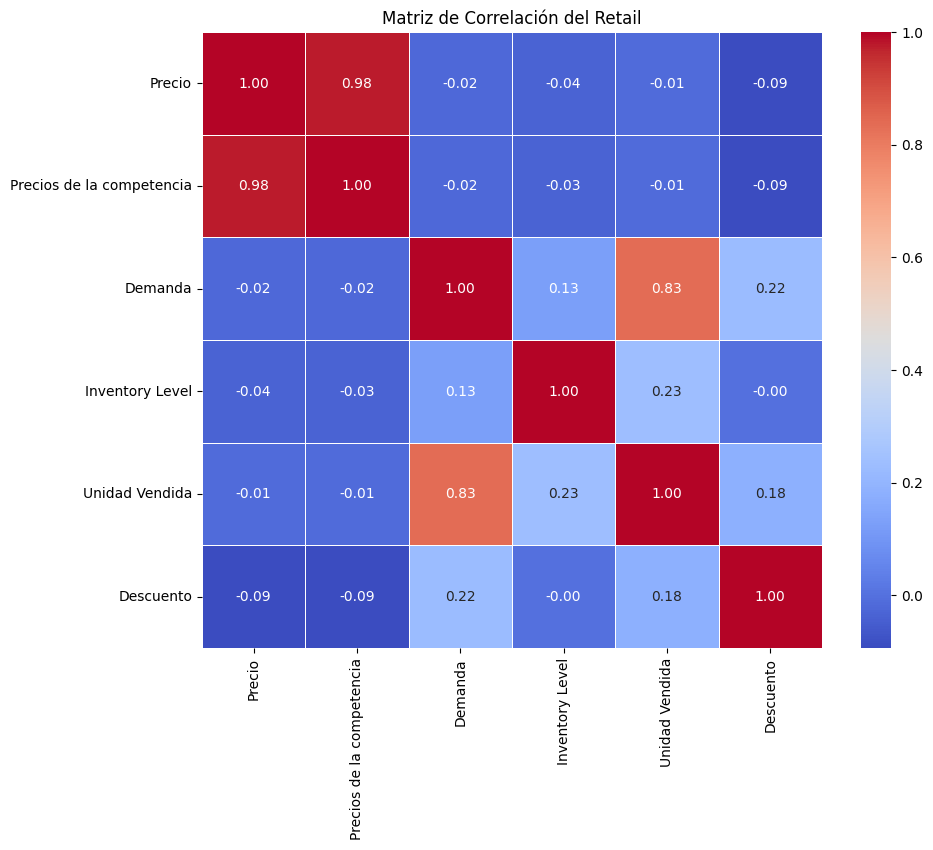

In [33]:
# Calculamos la correlación solo de las variables numéricas
corr = df[['Precio', 'Precios de la competencia', 'Demanda', 'Inventory Level', 'Unidad Vendida', 'Descuento']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación del Retail')
plt.show()

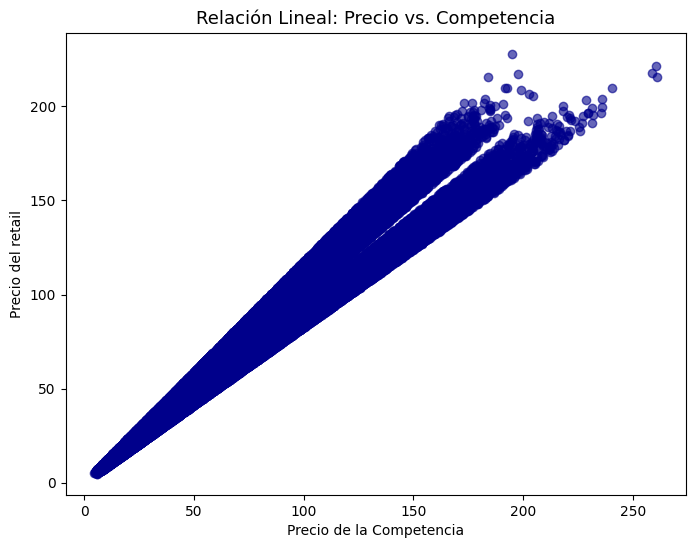

In [34]:
# Generando el Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Precios de la competencia'], df['Precio'], alpha=0.6, color='darkblue')

plt.title('Relación Lineal: Precio vs. Competencia', fontsize=13)
plt.xlabel('Precio de la Competencia')
plt.ylabel('Precio del retail')

plt.show()

In [35]:
# Cálculo de proporción
proporcion_missing = df.isnull().mean().sort_values(ascending=False)

In [36]:
# Vemos las columnas con más missings
print("Proporción de Missings:")
print(proporcion_missing.head(17))
# 2. Crear una lista de columnas a eliminar
# (En la guía, el umbral es 0, pero 'V' es el único con muchos missings)
drop_list = list(proporcion_missing[proporcion_missing > 0.4].index) # Eliminamos si falta más del 40%
print(f"\nColumnas a eliminar: {drop_list}")

# 3. Eliminar esas columnas del DataFrame
dataset = df.drop(labels=drop_list, axis=1)
print(f"\nForma de los datos después de eliminar: {dataset.shape}")

Proporción de Missings:
Fecha                        0.0
Store ID                     0.0
Product ID                   0.0
Categoria                    0.0
Region                       0.0
Inventory Level              0.0
Unidad Vendida               0.0
Unidades Ordenadas           0.0
Precio                       0.0
Descuento                    0.0
Condiciones Climaticas       0.0
Promoción                    0.0
Precios de la competencia    0.0
Estacionalidad               0.0
Epidemic                     0.0
Demanda                      0.0
dtype: float64

Columnas a eliminar: []

Forma de los datos después de eliminar: (76000, 16)


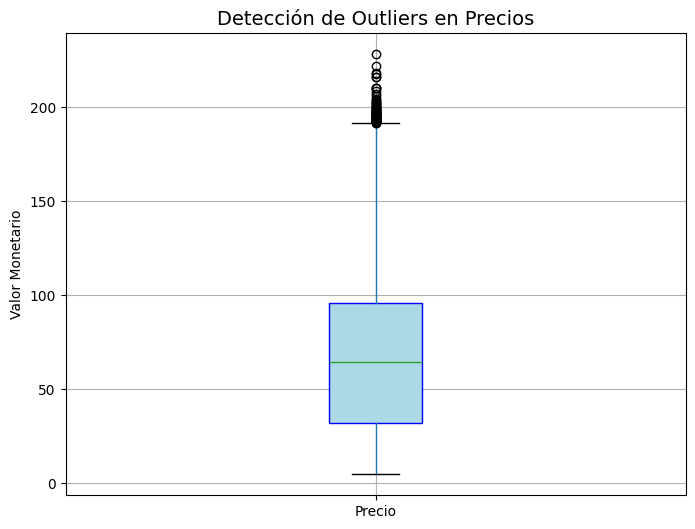

In [37]:
# Generamos el boxplot para detectar outliers en los precios
plt.figure(figsize=(8, 6))
df.boxplot(column=['Precio'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'))

plt.title('Detección de Outliers en Precios', fontsize=14)
plt.ylabel('Valor Monetario')
plt.show()

In [38]:
#ACCION 1
# 1. Normalización de la Demanda (Logaritmo)
# Sumamos 1 para evitar errores si hay valores en cero (log(0) no existe)
df['Demanda_Log'] = np.log1p(df['Demanda'])

# 2. Variación porcentual del Precio por tienda-producto
# pct_change() global mezcla productos distintos -> agrupamos por Store+Product
df['Variacion_Precio'] = (
    df.groupby(['Store ID', 'Product ID'])['Precio']
    .pct_change()
    .fillna(0)
)

In [39]:
#ACCION 2
from sklearn.preprocessing import StandardScaler

# Seleccionamos las variables que queremos estandarizar
variables_a_escalar = ['Precio', 'Inventory Level', 'Descuento', 'Demanda_Log']

scaler = StandardScaler()
df_escalado = scaler.fit_transform(df[variables_a_escalar])

# Lo convertimos de nuevo a un DataFrame para que sea legible
df_final = pd.DataFrame(df_escalado, columns=variables_a_escalar)

In [40]:
# Separamos solo las columnas numéricas
# Esto excluye automáticamente fechas y nombres de empresas si los hay
df_numerico = df.select_dtypes(include=[np.number])

# Excluimos Demanda_Log porque es transformacion directa de Demanda (redundante para PCA)
# Tambien excluimos Variacion_Precio por ser transformacion de Precio
df_numerico = df_numerico.drop(columns=['Demanda_Log', 'Variacion_Precio'], errors='ignore')

# 2. Ahora sí, estandarizamos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerico)

# 3. Aplicar PCA
pca = PCA()
pca_features = pca.fit_transform(df_scaled)


In [41]:
# Obtenemos los pesos (loadings) del primer componente (PC1)
pesos_pc1 = pca.components_[0]

# Creamos una serie de Pandas para asociar el nombre de la variable con su peso
#'df_numerico' es el que creamos antes con .select_dtypes(include=[np.number])
importancia_vars = pd.Series(pesos_pc1, index=df_numerico.columns)

# 3. Ordenamos de mayor a menor y tomamos las 10 principales
top_10_vars = importancia_vars.abs().sort_values(ascending=False).head(10)

print("Las 10 variables con mayor influencia en PC1 son:")
print(top_10_vars)

Las 10 variables con mayor influencia en PC1 son:
Demanda                      0.530251
Unidad Vendida               0.505382
Unidades Ordenadas           0.380172
Promoción                    0.363392
Descuento                    0.338247
Epidemic                     0.234193
Inventory Level              0.116022
Precio                       0.045783
Precios de la competencia    0.044989
dtype: float64


In [42]:
# Crear un DataFrame con los "Loadings"
#pca.components_ contiene los pesos de cada variable en cada componente
n_componentes = pca.components_.shape[0]
loadings = pd.DataFrame(
    pca.components_, # Todos los componentes disponibles
    columns=df_numerico.columns, # Nombres de las variables
    index=[f'PC{i+1}' for i in range(n_componentes)]
)

# 2. Ver el resultado
print("Matriz de Pesos (Loadings) - Primeros 5 componentes:")
print(loadings.head().round(3))

# 3. ¿Qué variables son las más importantes en PC1?
print("\nVariables que definen PC1 (ordenadas por peso):")
print(loadings.loc['PC1'].sort_values(ascending=False))

Matriz de Pesos (Loadings) - Primeros 5 componentes:
     Inventory Level  Unidad Vendida  Unidades Ordenadas  Precio  Descuento  \
PC1            0.116           0.505               0.380  -0.046      0.338   
PC2           -0.004           0.082               0.097   0.673     -0.165   
PC3           -0.266          -0.272              -0.040   0.192      0.564   
PC4            0.825           0.002              -0.468   0.061      0.187   
PC5            0.390           0.119               0.381   0.050     -0.125   

     Promoción  Precios de la competencia  Epidemic  Demanda  
PC1      0.363                     -0.045    -0.234    0.530  
PC2     -0.121                      0.672    -0.178    0.077  
PC3      0.560                      0.193     0.311   -0.226  
PC4      0.155                      0.063    -0.136   -0.122  
PC5     -0.078                      0.050     0.813    0.029  

Variables que definen PC1 (ordenadas por peso):
Demanda                      0.530251
Unidad 

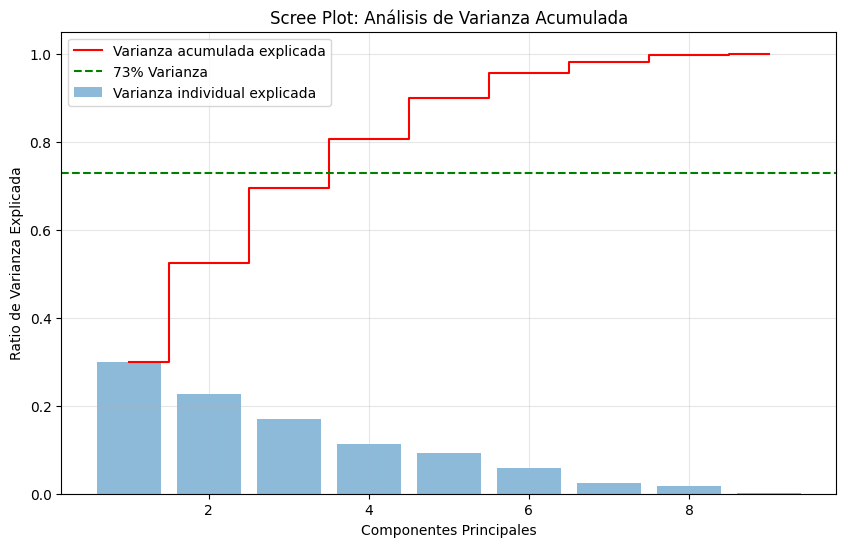

Varianza del PC1: 29.90%
Varianza acumulada con todos los componentes: 100.00%


In [43]:
#Calculamos la varianza
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

#Creamos el gráfico (Scree Plot)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center', label='Varianza individual explicada')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', label='Varianza acumulada explicada', color='red')

#Personalización del gráfico
plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Scree Plot: Análisis de Varianza Acumulada')
plt.axhline(y=0.73, color='g', linestyle='--', label='73% Varianza') # Línea de referencia
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

#Imprimimos los valores clave para tu texto
print(f"Varianza del PC1: {exp_var_pca[0]*100:.2f}%")
print(f"Varianza acumulada con todos los componentes: {cum_sum_eigenvalues[-1]*100:.2f}%")

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import linkage, dendrogram

In [45]:
# 1. Seleccionamos variables de comportamiento sin incluir demanda para que no existan redundancias o duplicados.
variables_cluster = ['Inventory Level', 'Unidad Vendida', 'Unidades Ordenadas',
                      'Precio', 'Descuento', 'Promoción',
                      'Precios de la competencia', 'Epidemic']

X_cluster = df[variables_cluster]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [46]:
# 2. K-MEANS: método del codo + silhouette para elegir k
inertias = []
sil_scores = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=101, n_init=4)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))



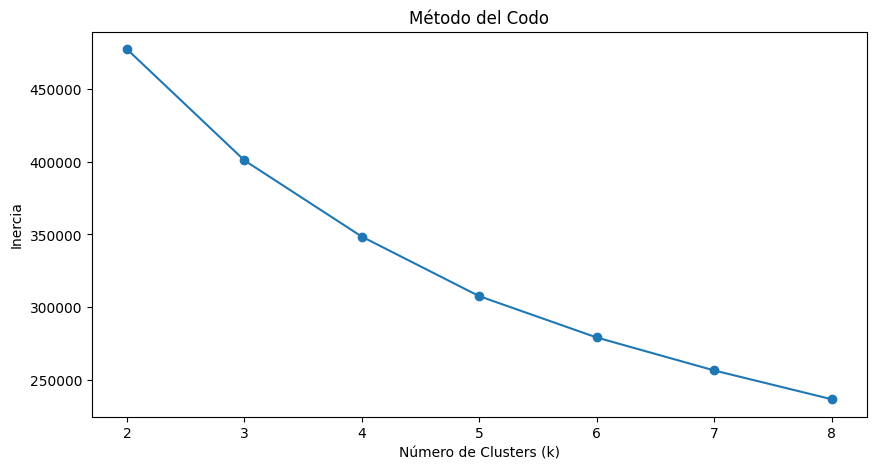

In [47]:
# Gráfico del codo
plt.figure(figsize=(10, 5))
plt.plot(rango_k, inertias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.show()


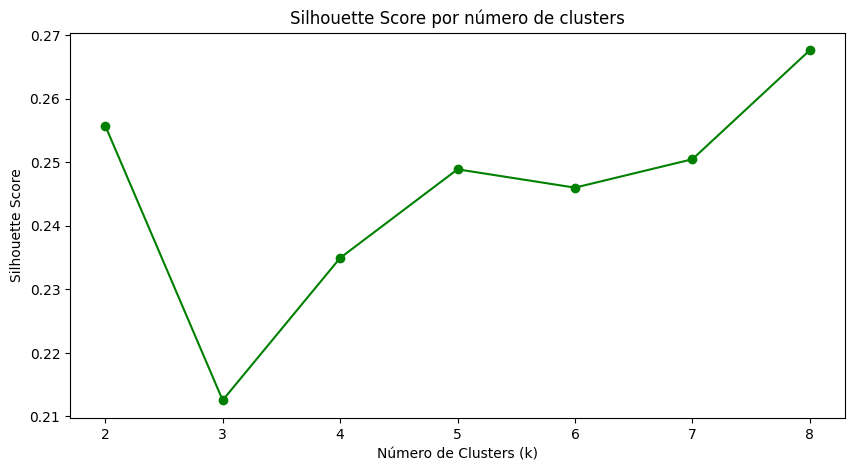

k=2 -> silhouette=0.256
k=3 -> silhouette=0.213
k=4 -> silhouette=0.235
k=5 -> silhouette=0.249
k=6 -> silhouette=0.246
k=7 -> silhouette=0.250
k=8 -> silhouette=0.268

K elegido automáticamente (mayor silhouette): 8


In [48]:
# Gráfico de silhouette (para justificar el k elegido)
plt.figure(figsize=(10, 5))
plt.plot(rango_k, sil_scores, marker='o', color='green')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

for k, s in zip(rango_k, sil_scores):
    print(f"k={k} -> silhouette={s:.3f}")
# Elegimos automáticamente el k con mayor silhouette
k_final = rango_k[int(np.argmax(sil_scores))]
print(f"\nK elegido automáticamente (mayor silhouette): {k_final}")    
    

In [49]:
# ------------------------------------------------------------
# 3. Entrenamos K-Means con el k elegido
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=k_final, random_state=101, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [50]:
# Diccionario que traduce el número de cluster a un nombre de negocio
# (ajusta el orden según lo que te salga a ti al correr tu propio dataset)
nombres_cluster = {
    0: 'Promocional estándar',
    1: 'Premium sin promoción',
    2: 'Alta reposición',
    3: 'Producto estrella',
    4: 'Económico estable',
    5: 'Baja rotación',
    6: 'Sobreinventario',
    7: 'Máxima demanda'
}

df['Cluster_Nombre'] = df['Cluster'].map(nombres_cluster)

In [51]:
# ------------------------------------------------------------
# 4. Interpretamos los clusters: perfil promedio de cada uno
# ------------------------------------------------------------
perfil_clusters = df.groupby('Cluster_Nombre')[variables_cluster + ['Demanda']].mean().round(2)
print("\nPerfil promedio por cluster (K-Means):")
(perfil_clusters)


Perfil promedio por cluster (K-Means):


,Inventory Level,Unidad Vendida,Unidades Ordenadas,Precio,Descuento,Promoción,Precios de la competencia,Epidemic,Demanda
Cluster_Nombre,,,,,,,,,
Alta reposición,257.09,99.14,101.16,107.72,16.75,1.00,111.13,0.01,120.53
Baja rotación,240.76,54.18,37.27,60.30,5.00,0.00,61.59,1.00,62.36
Económico estable,217.02,85.93,59.62,40.78,5.10,0.00,41.56,0.00,102.05
Máxima demanda,420.92,158.85,580.12,67.73,13.05,0.63,69.50,0.06,177.79
Premium sin promoción,250.06,79.55,60.06,114.26,4.62,0.00,117.55,0.02,93.41
Producto estrella,263.41,103.07,75.79,39.32,18.26,1.00,40.05,0.00,126.50
Promocional estándar,242.82,66.96,67.42,55.95,17.39,1.00,57.34,1.00,78.84
Sobreinventario,772.53,103.16,0.06,57.71,6.52,0.13,59.14,0.04,113.96


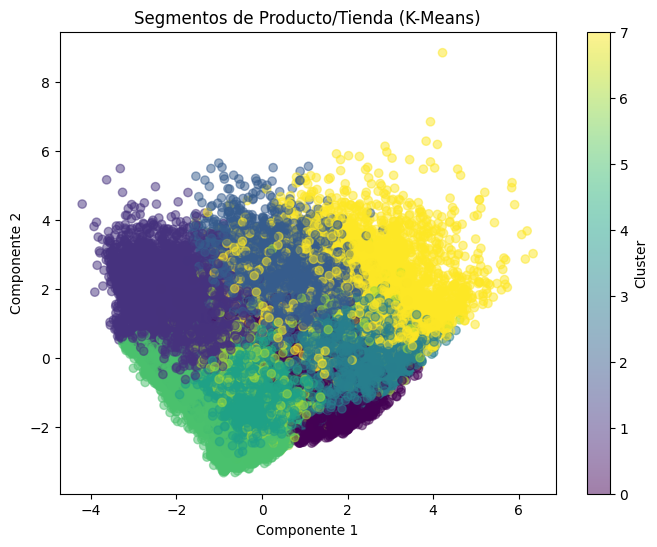

In [52]:
# 5. Visualización 2D del cluster
coords = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df['Cluster'],
                       cmap='viridis', alpha=0.5)
plt.title('Segmentos de Producto/Tienda (K-Means)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(scatter, label='Cluster')
plt.show()



Linkage calculado. Forma: (999, 4)


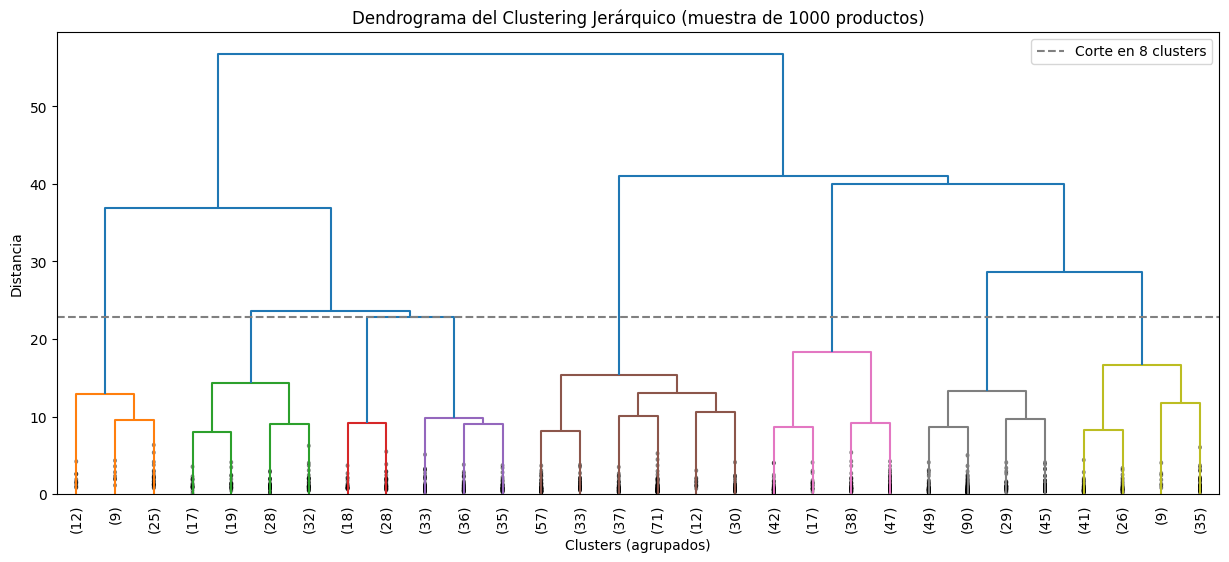

In [53]:
# 6. CLUSTERING JERÁRQUICO
#Con 76k filas el linkage completo no es viable por eso se trabaja sobre una muestra
df_muestra = df.sample(n=1000, random_state=101)
X_muestra = df_muestra[variables_cluster]
X_muestra_scaled = StandardScaler().fit_transform(X_muestra)
# method='ward' minimiza el aumento de varianza dentro de cada
# cluster al fusionar (equivalente jerárquico a lo que K-Means
# optimiza con la inercia)
link_muestra = linkage(X_muestra_scaled, method='ward')
print("\nLinkage calculado. Forma:", link_muestra.shape)

# Dendrograma: buscamos la altura de corte que da k_final clusters
plt.figure(figsize=(15, 6))
dendrogram(
    link_muestra,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    show_contracted=True,
    color_threshold=link_muestra[-(k_final - 1), 2]
)
plt.axhline(y=link_muestra[-(k_final - 1), 2], color='gray', linestyle='--',
            label=f'Corte en {k_final} clusters')
plt.legend()
plt.title('Dendrograma del Clustering Jerárquico (muestra de 1000 productos)')
plt.xlabel('Clusters (agrupados)')
plt.ylabel('Distancia')
plt.show()

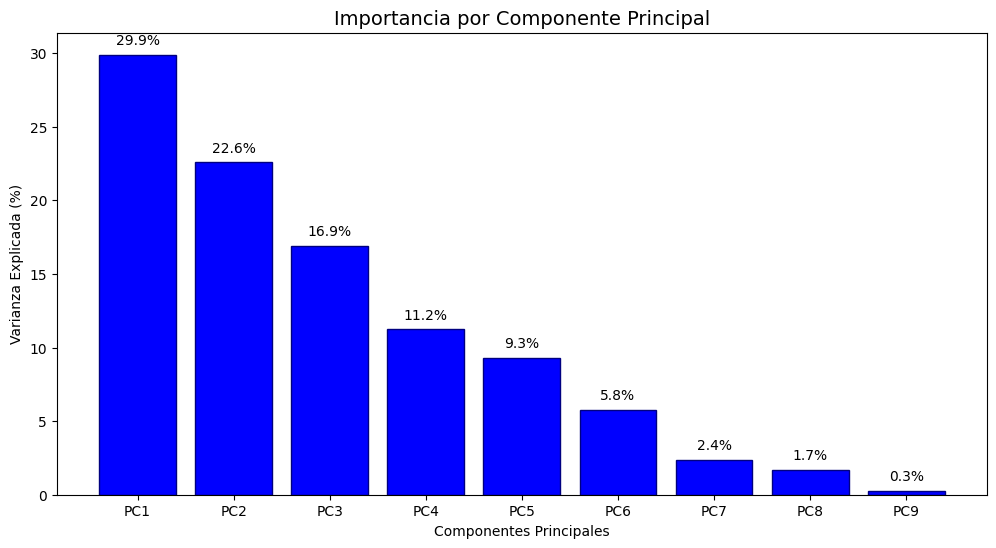

In [54]:
import matplotlib.pyplot as plt

#Extraemos la varianza de todos los componentes
n_comp = len(exp_var_pca)
componentes = [f'PC{i+1}' for i in range(n_comp)]
importancia = exp_var_pca * 100 # Multiplicamos por 100 para tener porcentaje

#Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
bars = plt.bar(componentes, importancia, color='blue', edgecolor='navy')

#Añadimos etiquetas de datos sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{round(yval, 1)}%', ha='center', va='bottom', fontsize=10)

plt.title('Importancia por Componente Principal', fontsize=14)
plt.ylabel('Varianza Explicada (%)')
plt.xlabel('Componentes Principales')

plt.show()

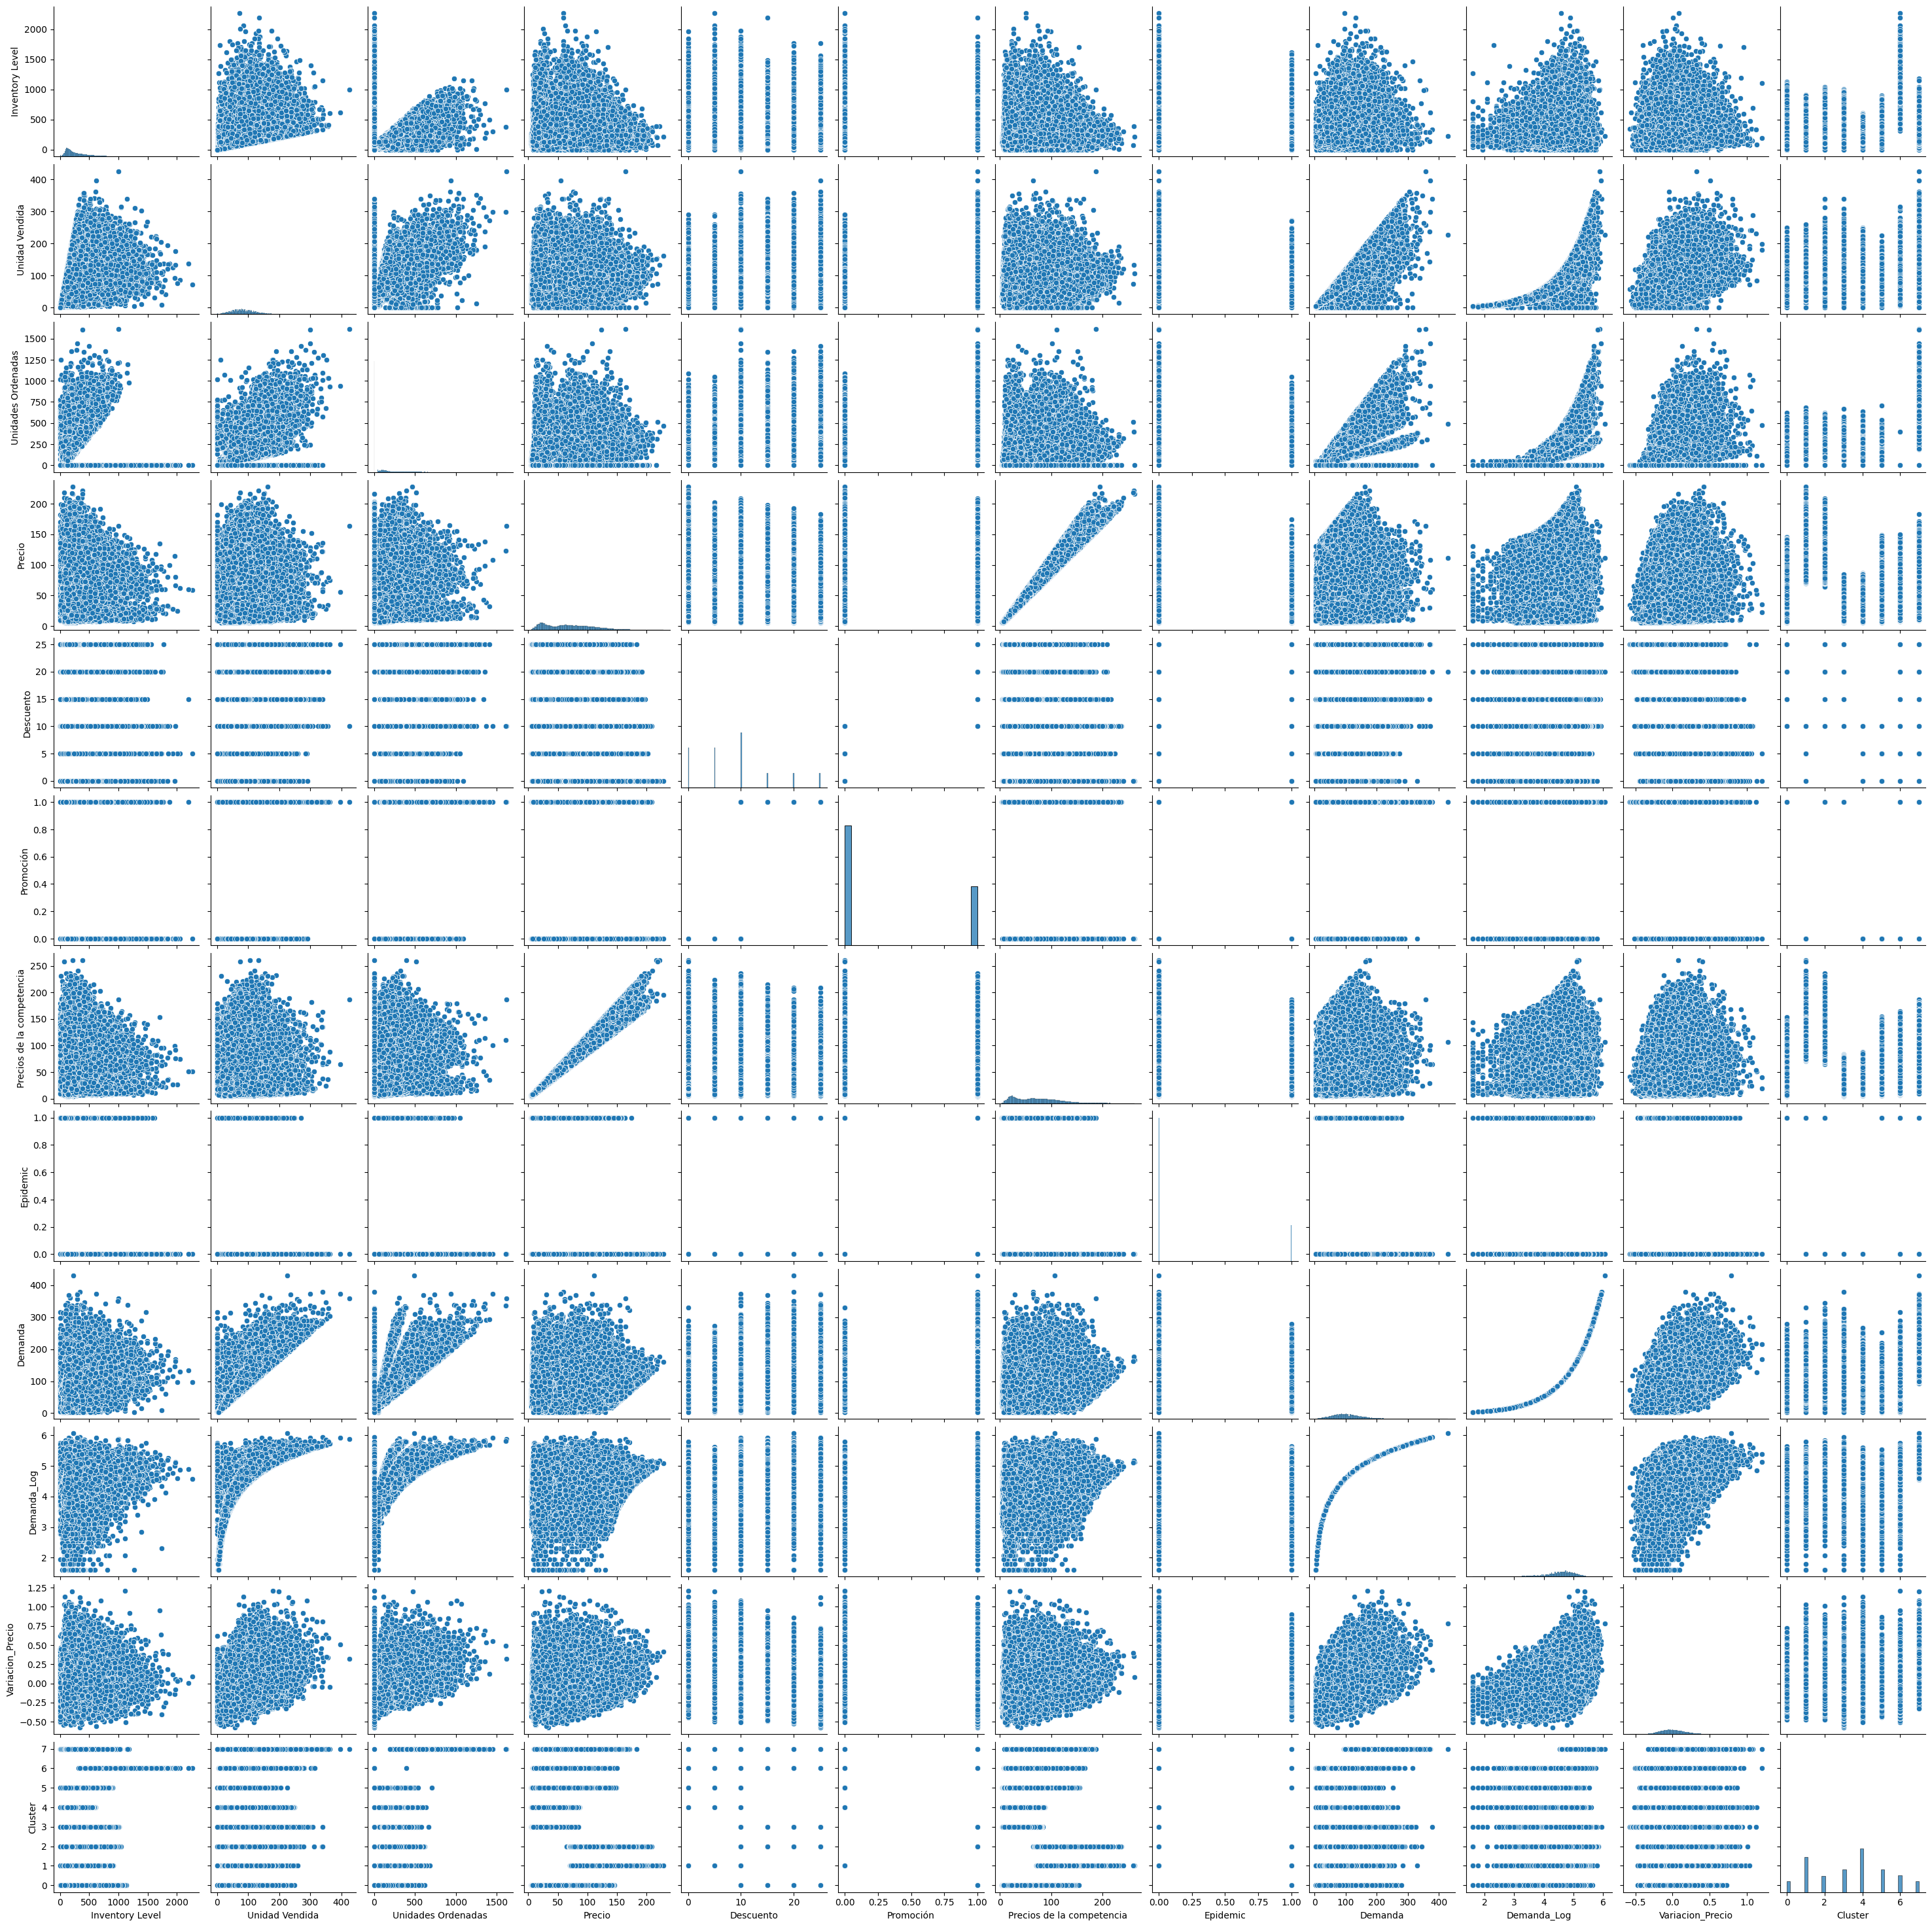

In [55]:
# 2. Ver relaciones (Pairplot)
sns.pairplot(df)

In [56]:
# ONE-HOT ENCODING para variables categóricas
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Categoria', 'Region', 'Condiciones Climaticas', 'Estacionalidad', 'Store ID']
encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = encoder.fit_transform(df[cat_cols])

# Nombres de las columnas one-hot
cat_names = encoder.get_feature_names_out(cat_cols)

# Variables numéricas originales para el modelo
num_cols = ['Inventory Level', 'Unidad Vendida', 'Unidades Ordenadas',
            'Precio', 'Descuento', 'Promoción',
            'Precios de la competencia', 'Epidemic']

# Combinar numéricas + one-hot
import numpy as np
X = np.hstack([df[num_cols].values, cat_encoded])
y = df['Demanda'].values

all_cols = list(num_cols) + list(cat_names)
print(f'Columnas one-hot: {cat_encoded.shape[1]}')
print(f'Total columnas finales: {X.shape[1]}')
print(f'Columnas: {all_cols}')

Columnas one-hot: 17
Total columnas finales: 25
Columnas: ['Inventory Level', 'Unidad Vendida', 'Unidades Ordenadas', 'Precio', 'Descuento', 'Promoción', 'Precios de la competencia', 'Epidemic', 'Categoria_Electronics', 'Categoria_Furniture', 'Categoria_Groceries', 'Categoria_Toys', 'Region_North', 'Region_South', 'Region_West', 'Condiciones Climaticas_Rainy', 'Condiciones Climaticas_Snowy', 'Condiciones Climaticas_Sunny', 'Estacionalidad_Spring', 'Estacionalidad_Summer', 'Estacionalidad_Winter', 'Store ID_S002', 'Store ID_S003', 'Store ID_S004', 'Store ID_S005']


In [57]:
from sklearn.model_selection import train_test_split

#Separar datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print("Datos separados correctamente")

Datos separados correctamente


In [58]:
from sklearn.linear_model import LinearRegression

# Entrenar el modelo
lm = LinearRegression()
lm.fit(X_train, y_train)

# Intercepto del modelo
print(f"Intercepto: {lm.intercept_}")
print(f"Pendiente:{lm.coef_[0]}")

Intercepto: 37.40725929656713
Pendiente:-0.0129080779276885


In [59]:
cdf = pd.DataFrame(lm.coef_, all_cols, columns=['Coeff'])
print(cdf)

                                  Coeff
Inventory Level               -0.012908
Unidad Vendida                 0.659132
Unidades Ordenadas             0.048326
Precio                         0.136090
Descuento                      0.063586
Promoción                     10.511180
Precios de la competencia      0.002997
Epidemic                     -17.244886
Categoria_Electronics         -8.373118
Categoria_Furniture          -25.348863
Categoria_Groceries            6.121012
Categoria_Toys                -2.877043
Region_North                   0.125619
Region_South                  -0.644807
Region_West                    0.155614
Condiciones Climaticas_Rainy  -3.674751
Condiciones Climaticas_Snowy  -3.803931
Condiciones Climaticas_Sunny   3.756070
Estacionalidad_Spring          1.160114
Estacionalidad_Summer          4.339396
Estacionalidad_Winter          1.590468
Store ID_S002                 -0.644807
Store ID_S003                  0.363574
Store ID_S004                  0.155614


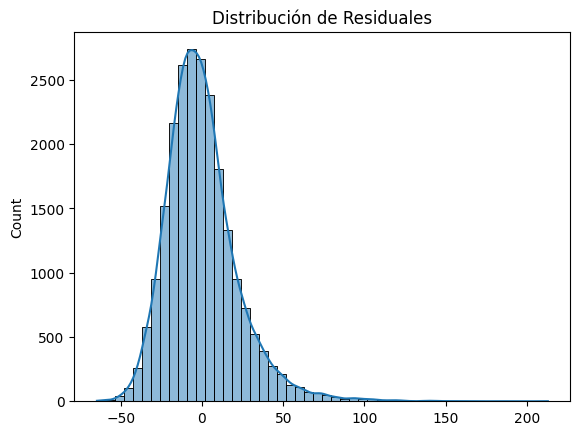

In [60]:
# Hacer predicciones
predictions = lm.predict(X_test)

sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title("Distribución de Residuales")
plt.show()

In [61]:
from sklearn import metrics
import numpy as np

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score:', metrics.r2_score(y_test, predictions))

MAE: 16.44344466831506
MSE: 492.97483929305747
RMSE: 22.20303671332049
R2 Score: 0.7774433155357137


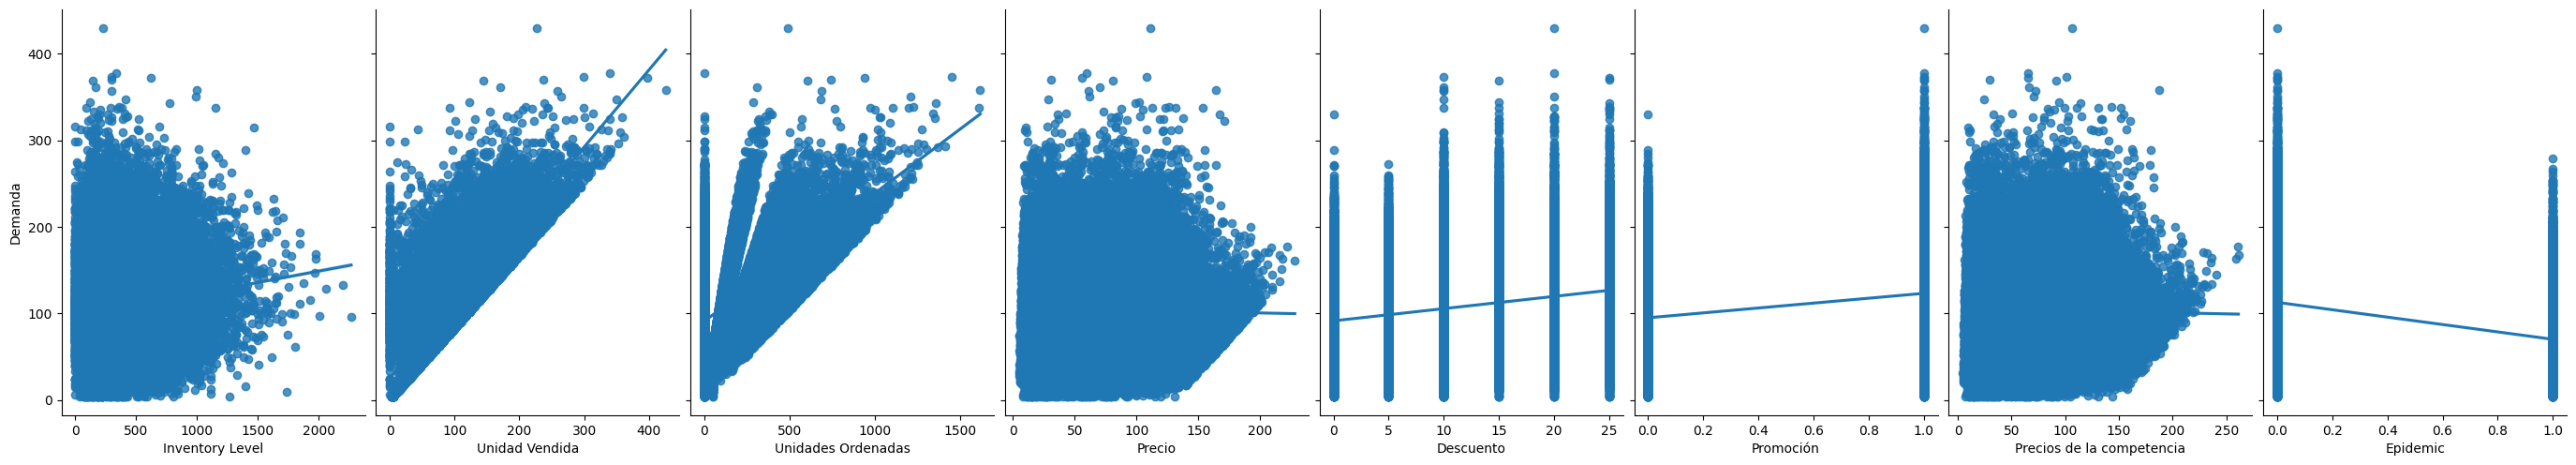

In [62]:
sns.pairplot(df, 
             x_vars=['Inventory Level', 'Unidad Vendida', 'Unidades Ordenadas',
        'Precio', 'Descuento',
        'Promoción', 'Precios de la competencia', 'Epidemic'], 
             y_vars='Demanda', 
             height=5, aspect=0.7, kind='reg')
plt.show()

In [63]:
from sklearn.model_selection import train_test_split

# Reutilizamos X e y ya construidos (numéricas + one-hot)
# Solo cambiamos el test_size a 0.2 para esta segunda prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print("Datos separados correctamente")

Datos separados correctamente


In [64]:
from sklearn.linear_model import LinearRegression

# Entrenar el modelo
lm = LinearRegression()
lm.fit(X_train, y_train)

# Intercepto del modelo
print(f"Intercepto: {lm.intercept_}")

Intercepto: 37.31103792296318


In [65]:
cdf = pd.DataFrame(lm.coef_, all_cols, columns=['Coeff'])
print(cdf)

                                  Coeff
Inventory Level               -0.012803
Unidad Vendida                 0.659995
Unidades Ordenadas             0.047820
Precio                         0.126692
Descuento                      0.060429
Promoción                     10.437554
Precios de la competencia      0.012766
Epidemic                     -17.271677
Categoria_Electronics         -8.506244
Categoria_Furniture          -25.450015
Categoria_Groceries            6.088366
Categoria_Toys                -3.009999
Region_North                   0.213879
Region_South                  -0.654844
Region_West                    0.179884
Condiciones Climaticas_Rainy  -3.742232
Condiciones Climaticas_Snowy  -3.757874
Condiciones Climaticas_Sunny   3.823307
Estacionalidad_Spring          1.334640
Estacionalidad_Summer          4.452358
Estacionalidad_Winter          1.537186
Store ID_S002                 -0.654844
Store ID_S003                  0.261080
Store ID_S004                  0.179884


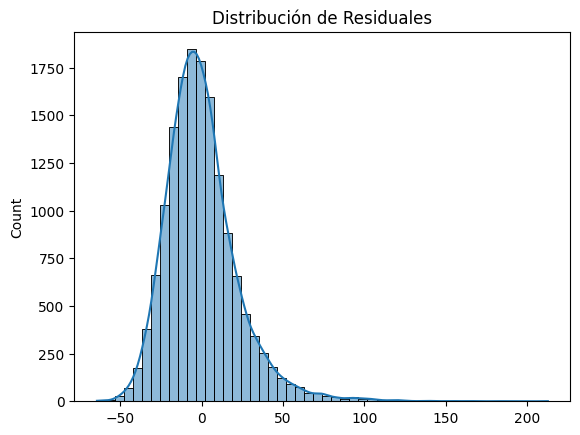

In [66]:
# Hacer predicciones
predictions = lm.predict(X_test)

sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title("Distribución de Residuales")
plt.show()

In [67]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predicciones sobre el conjunto de prueba
y_pred = lm.predict(X_test)

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# Calcular R2
r2 = r2_score(y_test, y_pred)
print(f'R2: {r2:.2f}')

RMSE: 22.25
R2: 0.78


In [68]:
#(Avance 2): MODELADO PREDICTIVO - CLASIFICACIÓN
# Objetivo: Clasificar productos en "Alta Demanda" vs "Baja Demanda"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, accuracy_score,
                              roc_curve, roc_auc_score)

In [69]:
# Crear la variable objetivo categórica a partir de 'Demanda'
mediana_demanda = df['Demanda'].median()
df['Alta_Demanda'] = (df['Demanda'] > mediana_demanda).astype(int)

print(f"Mediana de Demanda usada como punto de corte: {mediana_demanda:.2f}")
print(df['Alta_Demanda'].value_counts(normalize=True).round(3))
# Debe salir ~50%/50% porque se utiliza la mediana como corte

Mediana de Demanda usada como punto de corte: 100.00
Alta_Demanda
0    0.503
1    0.497
Name: proportion, dtype: float64


In [70]:
# 2. Variables predictoras (mismas numéricas que regresión, SIN
#    'Demanda' ni 'Unidad Vendida' para evitar fuga de datos)
#    Más las variables categóricas codificadas con OneHot

num_cols_clf = ['Inventory Level', 'Unidades Ordenadas', 'Precio',
                'Descuento', 'Promoción',
                'Precios de la competencia', 'Epidemic']

# Re-aplicar OneHot (el encoder ya está entrenado de la celda anterior)
cat_encoded_clf = encoder.transform(df[cat_cols])

# Combinar numéricas (sin Unidad Vendida) + one-hot
X = np.hstack([df[num_cols_clf].values, cat_encoded_clf])
y = df['Alta_Demanda'].values


In [71]:
# 3. Separar entrenamiento/prueba y escalar
#    (Regresión Logística sí es sensible a la escala de las variables)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [72]:
# 4. Entrenar el modelo de clasificación
modelo_clf = LogisticRegression(random_state=101)
modelo_clf.fit(X_train_scaled, y_train)

y_pred = modelo_clf.predict(X_test_scaled)
y_proba = modelo_clf.predict_proba(X_test_scaled)[:, 1]


Accuracy: 0.762

Reporte de clasificación:
              precision    recall  f1-score   support

Baja Demanda       0.77      0.76      0.76     11465
Alta Demanda       0.76      0.76      0.76     11335

    accuracy                           0.76     22800
   macro avg       0.76      0.76      0.76     22800
weighted avg       0.76      0.76      0.76     22800



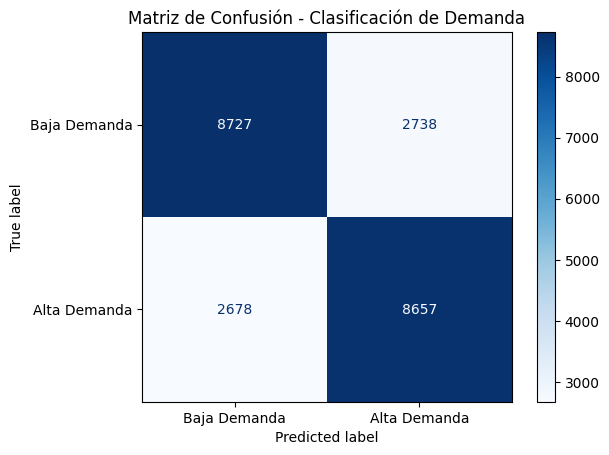

In [73]:
# 5. Evaluar el modelo

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Baja Demanda', 'Alta Demanda']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Baja Demanda', 'Alta Demanda'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Clasificación de Demanda')
plt.show()



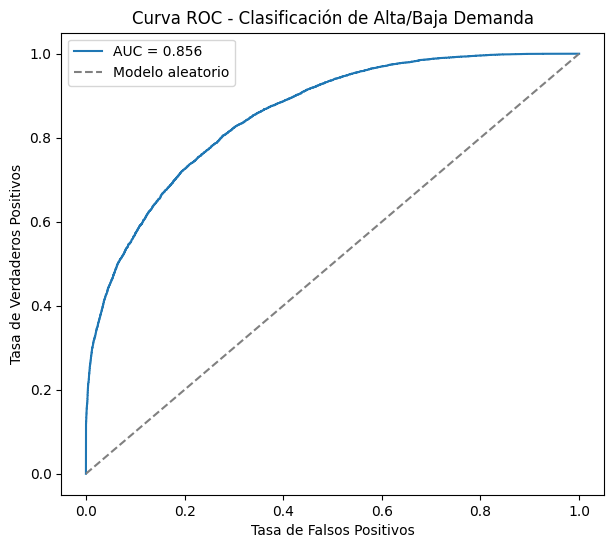

In [74]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')
plt.title('Curva ROC - Clasificación de Alta/Baja Demanda')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

In [75]:
# 6. Interpretar qué variables más influyen (coeficientes)
all_var_names_clf = list(num_cols_clf) + list(cat_names)
coef_df = pd.DataFrame({
    'Variable': all_var_names_clf,
    'Coeficiente': modelo_clf.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print("\nInfluencia de cada variable en la probabilidad de 'Alta Demanda' (top 10):")
print(coef_df.head(10))


Influencia de cada variable en la probabilidad de 'Alta Demanda' (top 10):
                        Variable  Coeficiente
1             Unidades Ordenadas     1.501134
2                         Precio     0.569873
4                      Promoción     0.479706
9            Categoria_Groceries     0.330839
0                Inventory Level     0.222095
16  Condiciones Climaticas_Sunny     0.191326
5      Precios de la competencia     0.148990
18         Estacionalidad_Summer     0.141586
3                      Descuento     0.080088
17         Estacionalidad_Spring     0.061723


In [76]:
print(f"Accuracy del modelo: {acc:.1%}")
print(f"AUC: {auc:.3f}")
print("Variable con mayor influencia positiva:", coef_df.iloc[0]['Variable'])
print("Variable con mayor influencia negativa:", coef_df.iloc[-1]['Variable'])

Accuracy del modelo: 76.2%
AUC: 0.856
Variable con mayor influencia positiva: Unidades Ordenadas
Variable con mayor influencia negativa: Categoria_Furniture



Accuracy (Random Forest): 0.848

Reporte de clasificación (Random Forest):
              precision    recall  f1-score   support

Baja Demanda       0.85      0.85      0.85     11465
Alta Demanda       0.85      0.85      0.85     11335

    accuracy                           0.85     22800
   macro avg       0.85      0.85      0.85     22800
weighted avg       0.85      0.85      0.85     22800



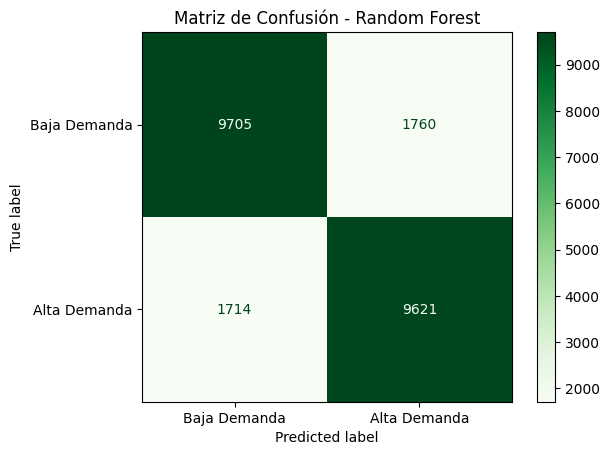

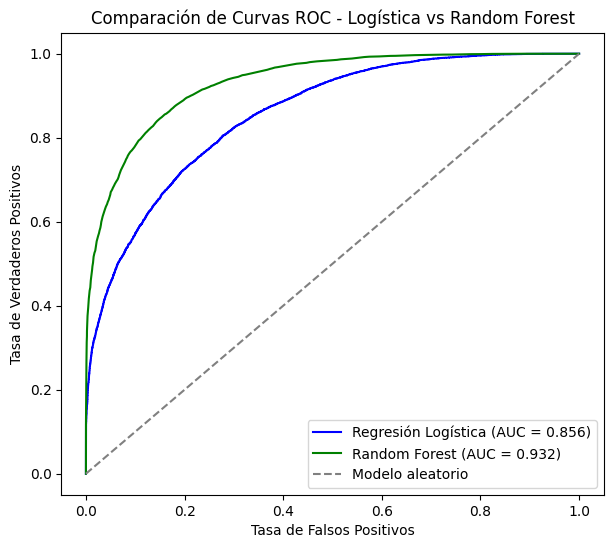


Importancia de variables según Random Forest (top 10):
                        Variable  Importancia
1             Unidades Ordenadas     0.199531
2                         Precio     0.170137
5      Precios de la competencia     0.144820
0                Inventory Level     0.132270
6                       Epidemic     0.067821
8            Categoria_Furniture     0.052111
3                      Descuento     0.045451
9            Categoria_Groceries     0.036360
4                      Promoción     0.028387
16  Condiciones Climaticas_Sunny     0.013271


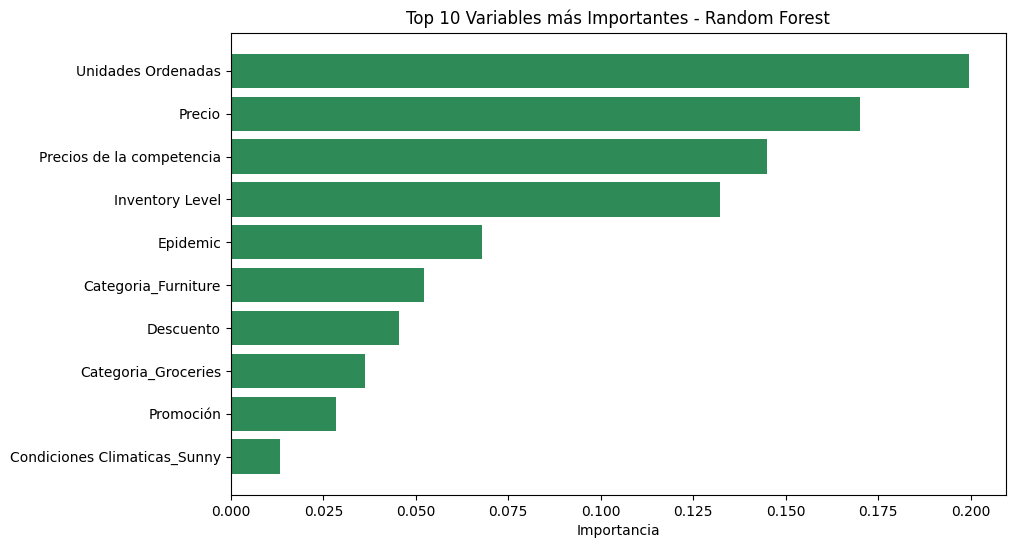


=== Comparación de Modelos ===
                Modelo  Accuracy       AUC
0  Regresión Logística  0.762456  0.855651
1        Random Forest  0.847632  0.931828


In [77]:

#MODELO COMPLEMENTARIO: RANDOM FOREST CLASSIFIER
# Comparación contra Regresión Logística
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, accuracy_score,
                              roc_curve, roc_auc_score)

# 1. Entrenar el modelo
# Random Forest no requiere escalado, usamos X_train / X_test originales
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=101)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

# 2. Evaluar el modelo
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy (Random Forest): {acc_rf:.3f}")
print("\nReporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Baja Demanda', 'Alta Demanda']))

# 3. Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Baja Demanda', 'Alta Demanda'])
disp_rf.plot(cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# 4. Curva ROC del Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# 5. Comparación de curvas ROC: Logística vs Random Forest
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc:.3f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')
plt.title('Comparación de Curvas ROC - Logística vs Random Forest')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

# 6. Importancia de variables (equivalente a los coeficientes de la logística)
# El orden de columnas en X es: num_cols_clf + cat_names
all_var_names = list(num_cols_clf) + list(cat_names)
importancia_rf = pd.DataFrame({
    'Variable': all_var_names,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de variables según Random Forest (top 10):")
print(importancia_rf.head(10))

plt.figure(figsize=(10, 6))
top10 = importancia_rf.head(10)
plt.barh(top10['Variable'], top10['Importancia'], color='seagreen')
plt.title('Top 10 Variables más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()

# 7. Tabla comparativa final entre ambos modelos
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [acc, acc_rf],
    'AUC': [auc, auc_rf]
})
print("\n=== Comparación de Modelos ===")
print(comparacion)